In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# Initial the exp assay path variable
exp_anno_local = None

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""exp_assays""","""DMS""","""#66BB6A""","""DMS""",-1
"""exp_assays""","""DMS_b""","""#66BB6A""","""DMS (combined)""",-1
"""exp_assays""","""GCK_activity""","""#66BB6A""","""GCK activity""",-1
"""exp_assays""","""GCK_abundance""","""#81C784""","""GCK abundance""",-1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [4]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

# olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']

anno = (
    anno
    .filter(
        # Always-applied filters
        # (pl.col('region').is_in(gene_trait_df['region'].unique()) | pl.col('region').is_in(olink_whitelist['region'].unique())),
        pl.col('region').is_in(gene_trait_df['region'].unique()),

        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-")
    )
    .with_columns(
        pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
        pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(id_cols + ['gene_name'])
    # .with_columns(
    #     dataset = pl.lit('UK Biobank WGS')
    # )
    .collect()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_372230/3130283119.py:31: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,gene_name
str,i64,str,str,str
"""R""",599,"""Q""","""ENSG00000077044""","""DGKD"""
"""Y""",357,"""C""","""ENSG00000117724""","""CENPF"""
"""S""",549,"""I""","""ENSG00000125386""","""FAM193A"""
"""V""",2458,"""I""","""ENSG00000143341""","""HMCN1"""
"""S""",241,"""L""","""ENSG00000165458""","""INPPL1"""
…,…,…,…,…
"""D""",190,"""A""","""ENSG00000119139""","""TJP2"""
"""P""",827,"""LX""","""ENSG00000143382""","""ADAMTSL4"""
"""K""",58,"""R""","""ENSG00000167701""","""GPT"""


## ProteinGym

In [6]:
# # ProteinGym DMS data

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"
exp_anno_filename = "DMS_ProteinGym_substitutions.parquet"

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
pg_df = (
    pl.read_parquet(exp_anno_local)
    .drop_nulls()
    .select(id_cols + ['file_name'])
    .unique()
    .rename({'file_name': 'assay'})
    .with_columns(
        dataset = pl.lit('ProteinGym')
    )
)

pg_df

Error: path "/home/dnanexus/data_dir/experimental_assays/DMS_ProteinGym_substi
tutions.parquet" already exists but -f/--overwrite was not set


ref_aa,aa_position,alt_aa,region,assay,dataset
str,i64,str,str,str,str
"""D""",119,"""S""","""ENSG00000174775""","""RASH_HUMAN_Bandaru_2017""","""ProteinGym"""
"""T""",91,"""C""","""ENSG00000103275""","""UBC9_HUMAN_Weile_2017""","""ProteinGym"""
"""I""",9,"""K""","""ENSG00000160791""","""CCR5_HUMAN_Gill_2023""","""ProteinGym"""
"""S""",162,"""E""","""ENSG00000138109""","""CP2C9_HUMAN_Amorosi_2021_activ…","""ProteinGym"""
"""C""",378,"""Q""","""ENSG00000169252""","""ADRB2_HUMAN_Jones_2020""","""ProteinGym"""
…,…,…,…,…,…
"""N""",471,"""V""","""ENSG00000197122""","""SRC_HUMAN_Nguyen_2022""","""ProteinGym"""
"""L""",112,"""F""","""ENSG00000284792""","""PTEN_HUMAN_Mighell_2018""","""ProteinGym"""
"""E""",285,"""A""","""ENSG00000138109""","""CP2C9_HUMAN_Amorosi_2021_abund…","""ProteinGym"""


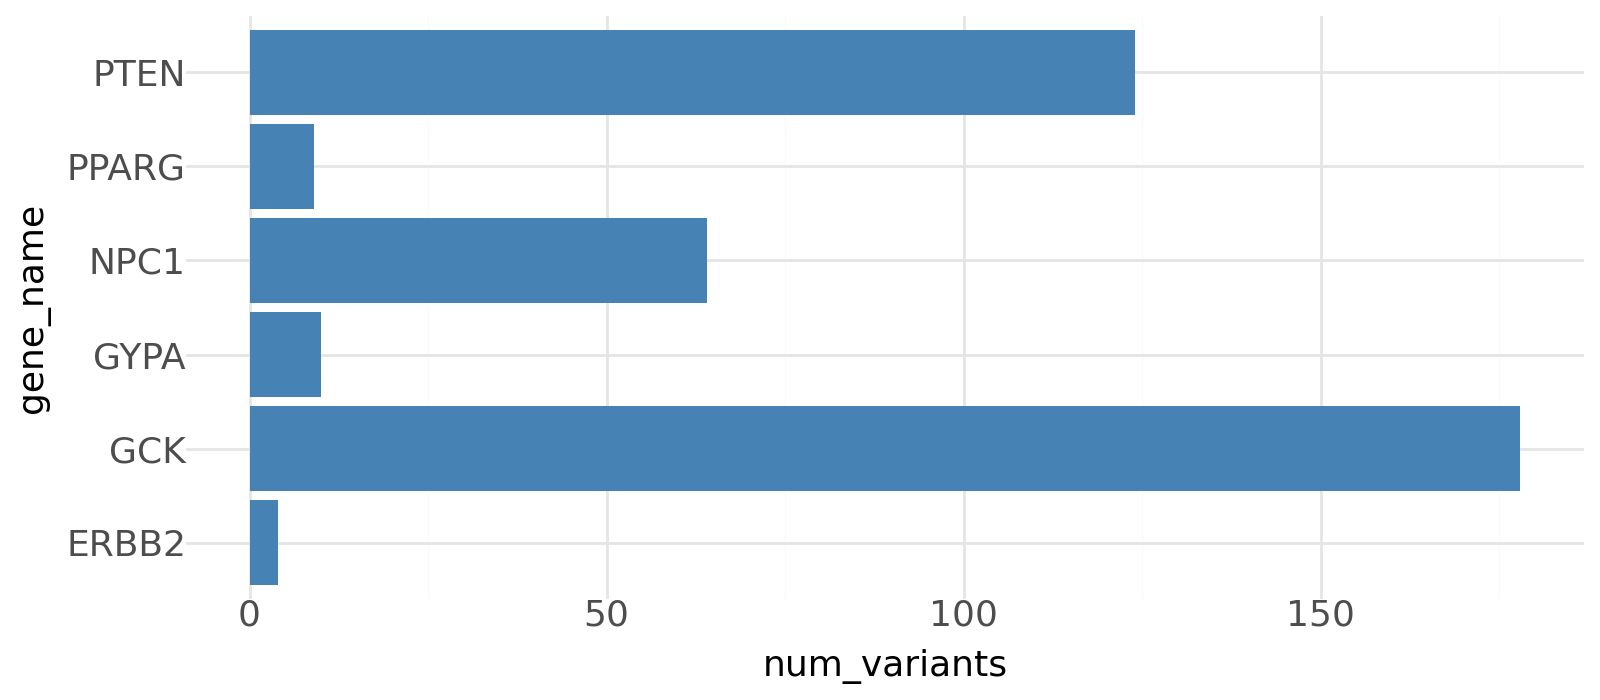

In [7]:
plot_ct = (
    anno
    .join(
        pg_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['dataset', 'assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)


(
    ggplot(plot_ct, aes(x='gene_name', y='num_variants'))
    + geom_bar(stat='identity', position='dodge', fill='steelblue')
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(8, plot_ct['gene_name'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Livesey and Marsh 2025
https://link.springer.com/article/10.1186/s13059-025-03575-w

In [8]:
# Marsh assays

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

exp_anno_filename = "DMS_Marsh_VEP.parquet"
exp_assay_type_column = 'DMS_assay'
exp_assay_score_column = 'DMS_score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
marsh_df = (
    pl.read_parquet(exp_anno_local)
    .drop_nulls()
    .select(id_cols + ['DMS_assay'])
    .unique()
    .rename({'DMS_assay': 'assay'})
    .with_columns(
        dataset = pl.lit('Livesey and Marsh 2025')
    )
)

# Remove the ones from ProteinGym
# marsh_df = (
#     marsh_df
#     .join(
#         pg_df,
#         on=id_cols+['DMS_score'],
#         how='anti'
#     )
# )

marsh_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/DMS_Marsh_VEP.parquet" already
exists but -f/--overwrite was not set


ref_aa,aa_position,alt_aa,region,assay,dataset
str,i64,str,str,str,str
"""P""",201,"""R""","""ENSG00000203879""","""DMS_b_refined""","""Livesey and Marsh 2025"""
"""K""",144,"""M""","""ENSG00000177000""","""DMS_12_A222V""","""Livesey and Marsh 2025"""
"""D""",47,"""F""","""ENSG00000276536""","""DMS_regulated""","""Livesey and Marsh 2025"""
"""G""",48,"""N""","""ENSG00000133703""","""DMS_urn-mavedb-00000115-a-3""","""Livesey and Marsh 2025"""
"""P""",443,"""G""","""ENSG00000177000""","""DMS_12_A222V""","""Livesey and Marsh 2025"""
…,…,…,…,…,…
"""L""",439,"""C""","""ENSG00000177000""","""DMS_100_A222V""","""Livesey and Marsh 2025"""
"""A""",42,"""S""","""ENSG00000100030""","""DMS_DOX""","""Livesey and Marsh 2025"""
"""S""",376,"""L""","""ENSG00000141510""","""DMS_null_etoposide""","""Livesey and Marsh 2025"""


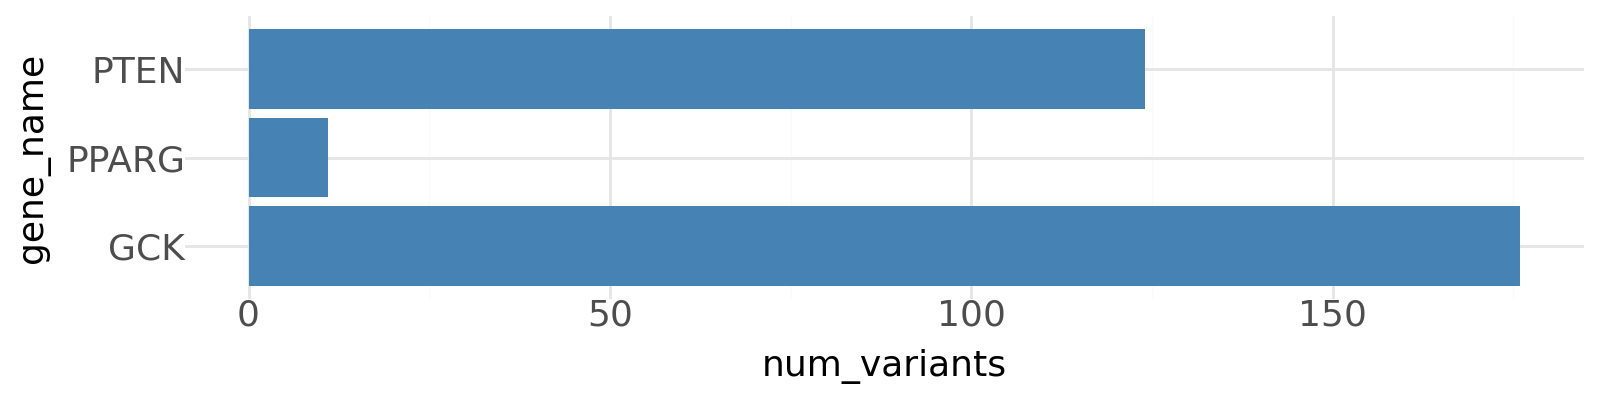

In [9]:
plot_ct = (
    anno
    .join(
        marsh_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)


(
    ggplot(plot_ct, aes(x='gene_name', y='num_variants'))
    + geom_bar(stat='identity', position='dodge', fill='steelblue')
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(8, plot_ct['gene_name'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## LDLR - Tabet et al. 2025

In [10]:
# Tabet LDLR assays

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
ldlr_df = (
    pl.read_parquet(exp_anno_local)
    .drop_nulls()
    .select(id_cols + ['assay'])
    .unique()
    .with_columns(
        dataset = pl.lit('Tabet LDLR 2025')
    )
)

ldlr_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquet"
already exists but -f/--overwrite was not set


ref_aa,aa_position,alt_aa,region,assay,dataset
str,i64,str,str,str,str
"""D""",858,"""N""","""ENSG00000130164""","""LDLR_cell_surface_abundance""","""Tabet LDLR 2025"""
"""T""",159,"""Q""","""ENSG00000130164""","""LDL_uptake_presence_VLDL_funct…","""Tabet LDLR 2025"""
"""C""",318,"""F""","""ENSG00000130164""","""LDL_uptake_presence_VLDL_funct…","""Tabet LDLR 2025"""
"""D""",112,"""W""","""ENSG00000130164""","""LDLR_cell_surface_abundance""","""Tabet LDLR 2025"""
"""S""",326,"""Q""","""ENSG00000130164""","""LDLR_cell_surface_abundance""","""Tabet LDLR 2025"""
…,…,…,…,…,…
"""S""",157,"""*""","""ENSG00000130164""","""LDL_uptake_presence_VLDL_funct…","""Tabet LDLR 2025"""
"""F""",32,"""A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""","""Tabet LDLR 2025"""
"""F""",512,"""T""","""ENSG00000130164""","""LDLR_cell_surface_abundance""","""Tabet LDLR 2025"""


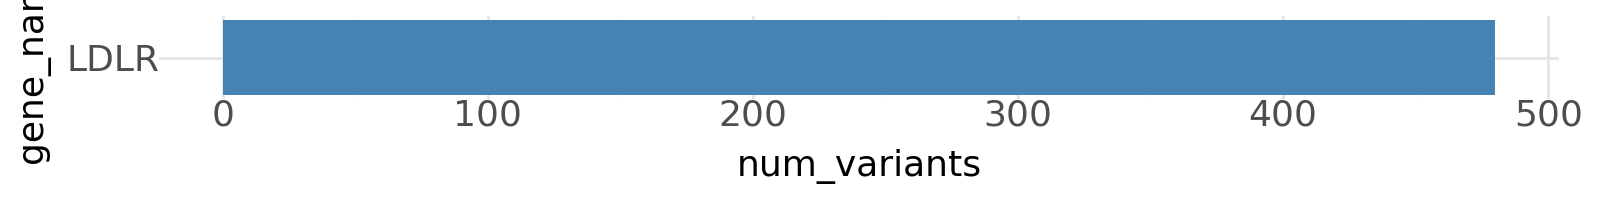

In [11]:
plot_ct = (
    anno
    .join(
        ldlr_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)


(
    ggplot(plot_ct, aes(x='gene_name', y='num_variants'))
    + geom_bar(stat='identity', position='dodge', fill='steelblue')
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(8, plot_ct['gene_name'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## aPCA - Beltran et al. 2025

In [12]:
# # aPCA assay

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays/aPCA_Beltran_Nature_2025.parquet -o {LOCAL_EXP_DIR}

exp_anno_local = f"{LOCAL_EXP_DIR}/aPCA_Beltran_Nature_2025.parquet"

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# One fitness score per variant, 447 genes
apca_df = (
    pl.read_parquet(exp_anno_local)
    .drop_nulls()
    .select(id_cols + ['uniprot_ID'])
    .unique()
    .rename({'uniprot_ID': 'assay'})
    .with_columns(
        dataset = pl.lit('Beltran aPCA 2025')
    )
)

apca_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/aPCA_Beltran_Nature_2025.parquet"
already exists but -f/--overwrite was not set


ref_aa,aa_position,alt_aa,region,assay,dataset
str,i64,str,str,str,str
"""A""",324,"""N""","""ENSG00000135679""","""Q00987""","""Beltran aPCA 2025"""
"""A""",970,"""P""","""ENSG00000113649""","""O14776""","""Beltran aPCA 2025"""
"""S""",30,"""T""","""ENSG00000122367""","""O75112""","""Beltran aPCA 2025"""
"""D""",753,"""Y""","""ENSG00000196935""","""Q7Z6B7""","""Beltran aPCA 2025"""
"""I""",506,"""N""","""ENSG00000060237""","""Q9H4A3""","""Beltran aPCA 2025"""
…,…,…,…,…,…
"""V""",597,"""T""","""ENSG00000189079""","""Q68CP9""","""Beltran aPCA 2025"""
"""K""",67,"""H""","""ENSG00000292301""","""Q8IV48""","""Beltran aPCA 2025"""
"""E""",1500,"""A""","""ENSG00000136068""","""O75369""","""Beltran aPCA 2025"""


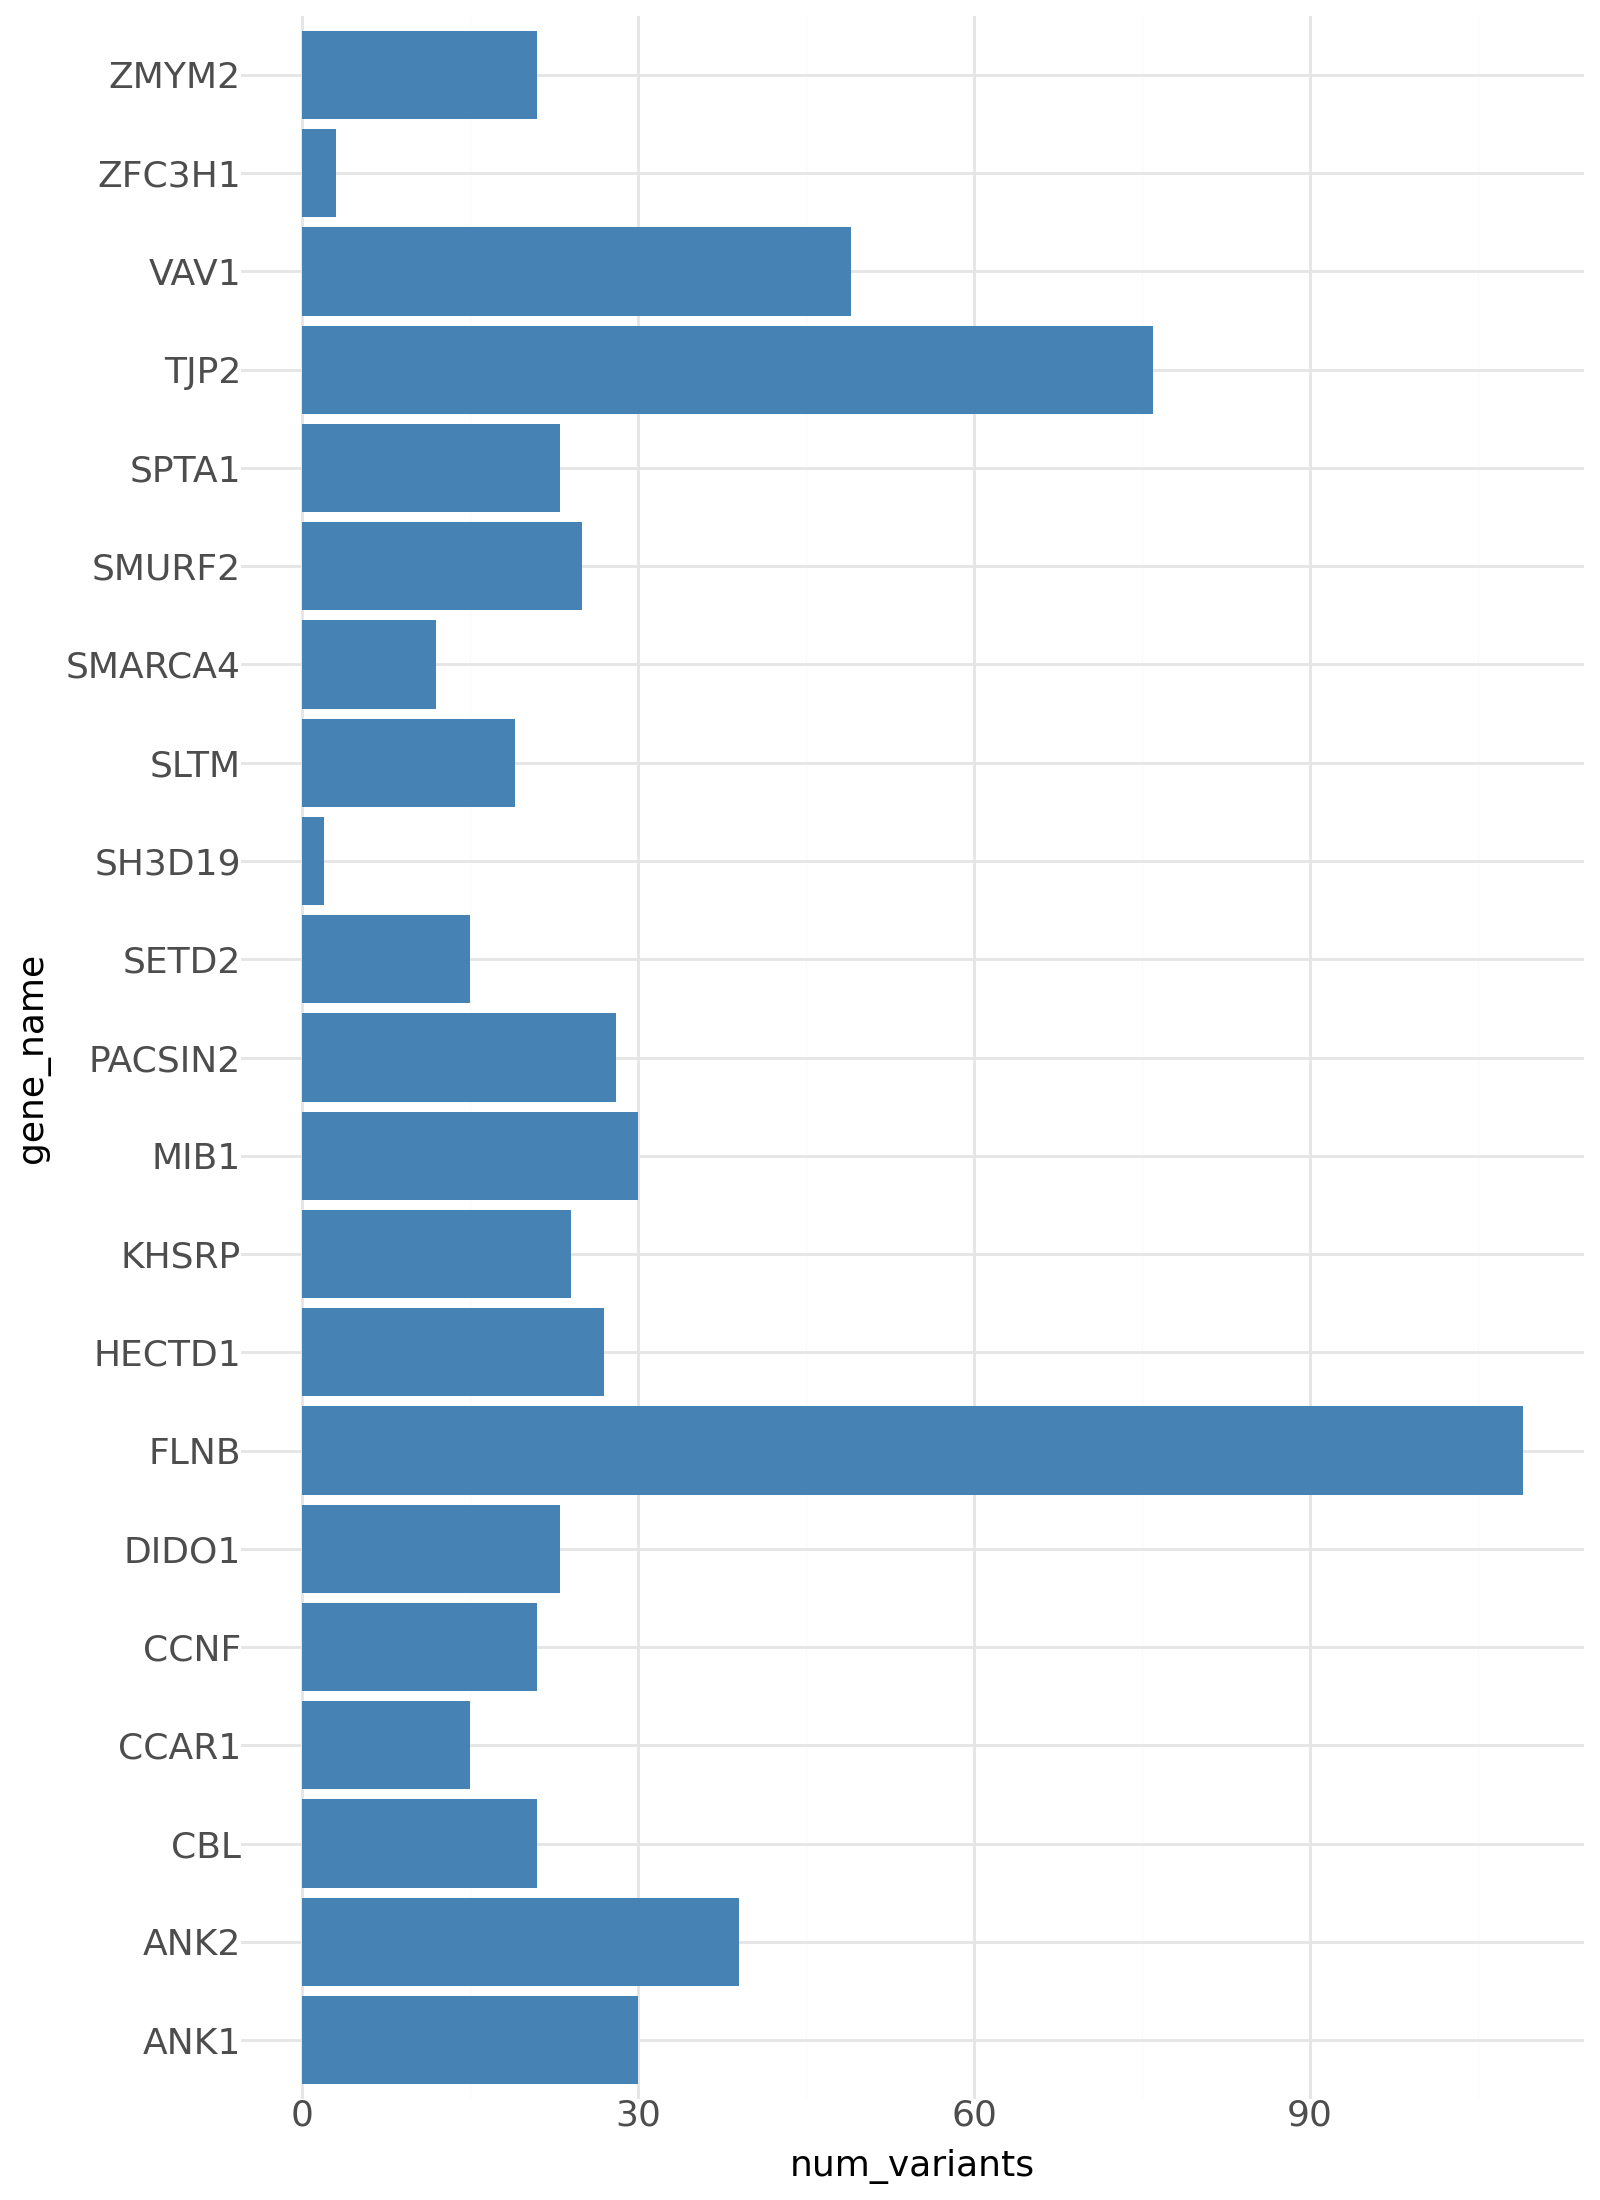

In [13]:
plot_ct = (
    anno
    .join(
        apca_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)


(
    ggplot(plot_ct, aes(x='gene_name', y='num_variants'))
    + geom_bar(stat='identity', position='dodge', fill='steelblue')
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(8, plot_ct['gene_name'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Combined plot

In [14]:
pg_ct = (
    anno
    .join(
        pg_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['dataset', 'assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)

marsh_ct = (
    anno
    .join(
        marsh_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['dataset', 'assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)

ldlr_ct = (
    anno
    .join(
        ldlr_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['dataset', 'assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)

apca_ct = (
    anno
    .join(
        apca_df,
        on=id_cols,
        how='inner'
    )

    .group_by(['dataset', 'assay', 'gene_name'])
    .agg(
        num_variants = pl.len()
    )
    .sort('num_variants', descending=True)
)

all_cts = pl.concat([pg_ct, marsh_ct, ldlr_ct, apca_ct], how='vertical').sort('num_variants', descending=True)

all_cts

dataset,assay,gene_name,num_variants
str,str,str,u64
"""Tabet LDLR 2025""","""LDL_uptake_functional""","""LDLR""",480
"""Tabet LDLR 2025""","""LDLR_cell_surface_abundance""","""LDLR""",467
"""Tabet LDLR 2025""","""LDL_uptake_presence_VLDL_funct…","""LDLR""",206
"""ProteinGym""","""HXK4_HUMAN_Gersing_2023_abunda…","""GCK""",178
"""ProteinGym""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""",176
…,…,…,…
"""ProteinGym""","""PPARG_HUMAN_Majithia_2016""","""PPARG""",9
"""ProteinGym""","""ERBB2_HUMAN_Elazar_2016""","""ERBB2""",4
"""ProteinGym""","""NPC1_HUMAN_Erwood_2022_RPE1""","""NPC1""",4


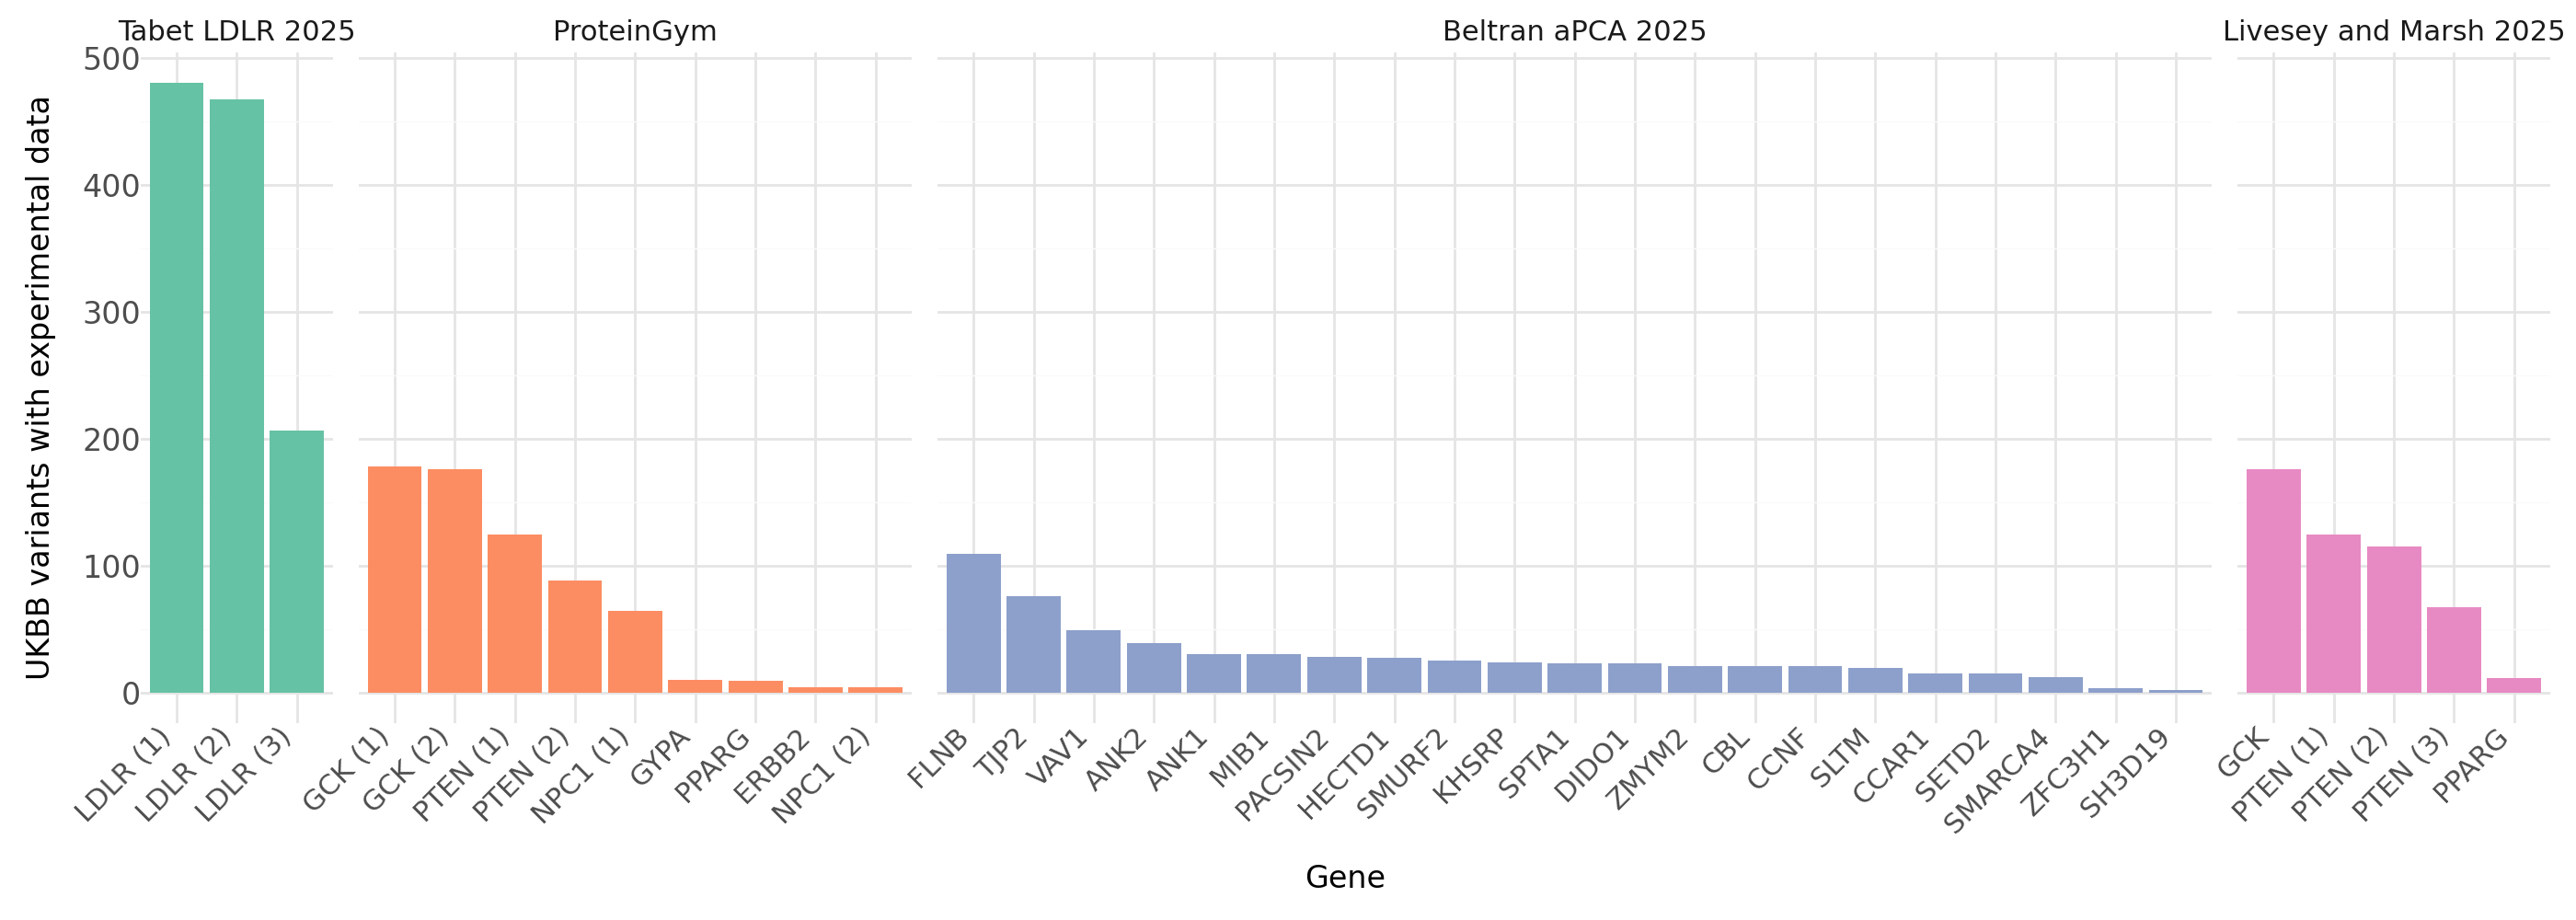

In [17]:
all_cts_pd = all_cts.to_pandas()

# Facet order: datasets sorted by total num_variants descending
dataset_order = (
    all_cts_pd.groupby('dataset')['num_variants'].sum()
    .sort_values(ascending=False).index.tolist()
)

# Within each dataset, sort by num_variants descending, then assign ordinal per gene
all_cts_pd = all_cts_pd.sort_values(['dataset', 'num_variants'], ascending=[True, False])
all_cts_pd['assay_rank'] = (
    all_cts_pd.groupby(['dataset', 'gene_name']).cumcount() + 1
)
assay_counts = all_cts_pd.groupby(['dataset', 'gene_name'])['assay'].count().rename('assay_count').reset_index()
all_cts_pd = all_cts_pd.merge(assay_counts, on=['dataset', 'gene_name'])

# Display label: gene_name for single-assay, gene_name (n) for multi-assay
def make_label(row):
    if row['assay_count'] == 1:
        return row['gene_name']
    return f"{row['gene_name']} ({int(row['assay_rank'])})"

all_cts_pd['x_label'] = all_cts_pd.apply(make_label, axis=1)

# Unique x_id per bar for ordering
all_cts_pd['x_id'] = all_cts_pd['gene_name'] + '||' + all_cts_pd['assay']

# Global x_id order: by dataset (descending total), then within each dataset by num_variants descending
x_order = []
for ds in dataset_order:
    sub = all_cts_pd[all_cts_pd['dataset'] == ds].sort_values('num_variants', ascending=False)
    x_order.extend(sub['x_id'].tolist())

label_map = dict(zip(all_cts_pd['x_id'], all_cts_pd['x_label']))

all_cts_pd['x_id'] = pd.Categorical(all_cts_pd['x_id'], categories=x_order, ordered=True)
all_cts_pd['dataset'] = pd.Categorical(all_cts_pd['dataset'], categories=dataset_order, ordered=True)

n_bars = len(x_order)
(
    ggplot(all_cts_pd, aes(x='x_id', y='num_variants', fill='dataset'))
    + geom_bar(stat='identity')
    + facet_grid('~dataset', scales='free_x', space='free_x')
    + scale_x_discrete(labels=label_map)
    + scale_fill_brewer(type='qual', palette='Set2')
    + labs(
        x = "Gene",
        y = "UKBB variants with experimental data",
    )
    + theme_minimal()
    + theme(
        figure_size=(14, 5),
        legend_position="none",
        axis_text=element_text(size=12),
        axis_text_x=element_text(size=11, rotation=45, ha='right'),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)